# Erosion and Dilation
## Name: Aaron I.
## Register Number:212223230002

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Replace 'ABCDE' with your name (only the first 5 characters)
name = 'AARON'

In [3]:
def load_img():
    blank_img =np.zeros((600,600))
    font = cv2.FONT_HERSHEY_SIMPLEX
    cv2.putText(blank_img,text='AARON',org=(50,300), fontFace=font,fontScale= 5,color=(255,255,255),thickness=25,lineType=cv2.LINE_AA)
    return blank_img

In [4]:
def display_img(img):
    fig = plt.figure(figsize=(12,10))
    ax = fig.add_subplot(111)
    ax.imshow(img,cmap='gray')
    plt.show()

In [5]:
img = load_img()

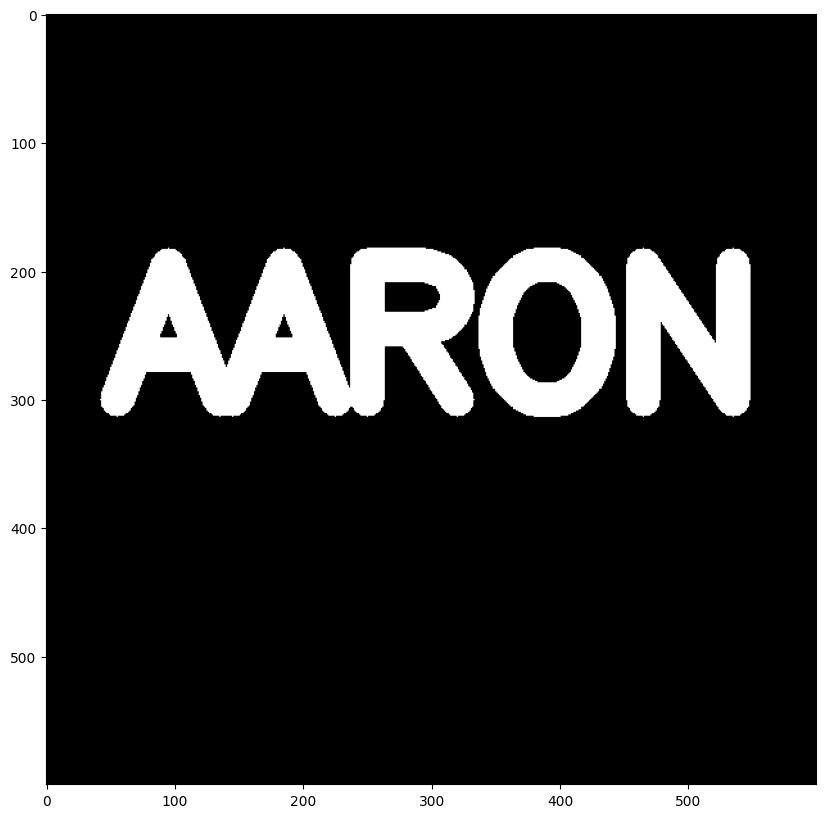

In [6]:
display_img(img)

## Erosion

Erodes away boundaries of foreground objects. Works best when foreground is light color (preferrably white) and background is dark.

In [7]:
# Create a 5x5 kernel filled with ones and display it using dtype=np.uint8

In [8]:
kernel = np.ones((5,5),dtype=np.uint8)

In [9]:
kernel.shape

(5, 5)

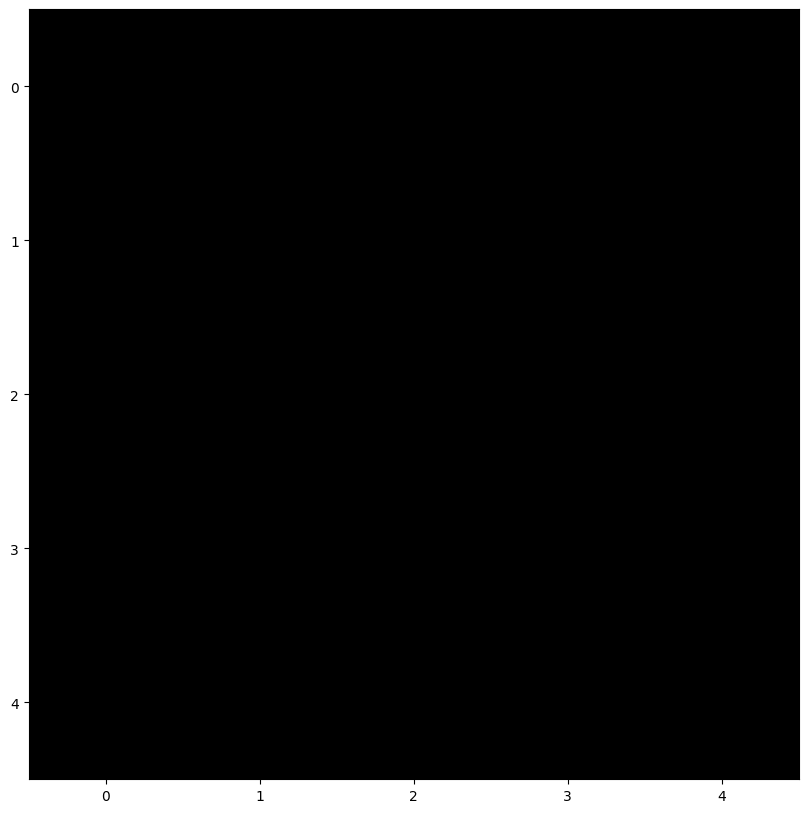

In [10]:
display_img(kernel)

In [11]:
kernel

array([[1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1]], dtype=uint8)

In [12]:
# Apply erosion on the image using the specified kernel with one iteration and store the result in erosion1 using the cv2.erode() function.

In [13]:
erosion1 = cv2.erode(img, kernel, iterations=1)

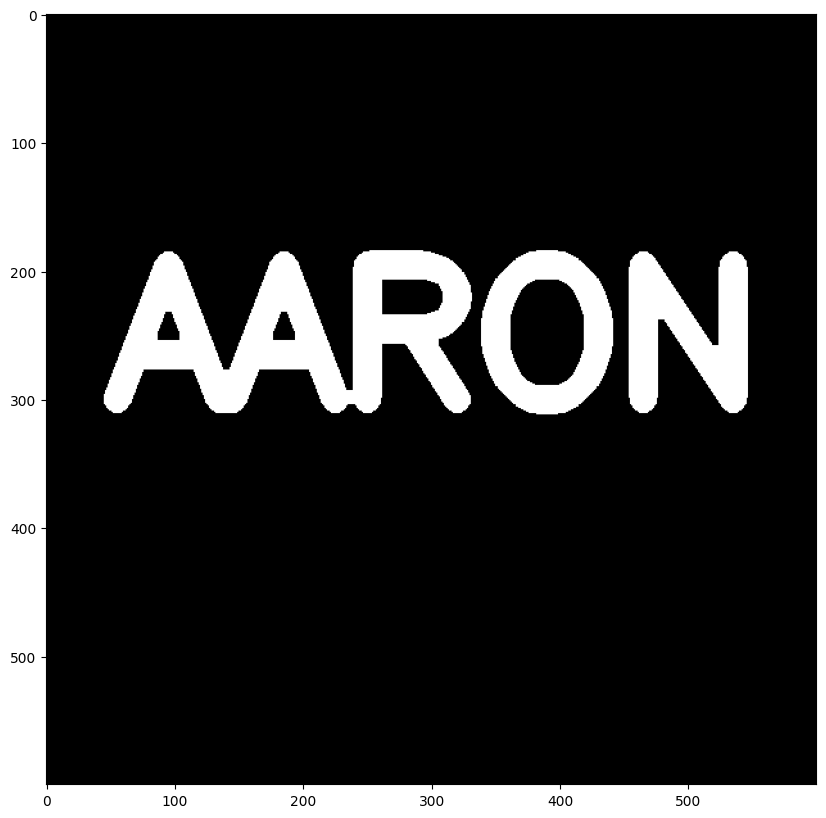

In [14]:
display_img(erosion1)

## Opening
Opening is erosion followed by dilation. Useful in removing background noise!

In [15]:
img = load_img()

In [16]:
# creat white noise  with randint(low=0,high=3,size=(600,600)) 

In [17]:
white_noise = np.random.randint(low=0,high=3,size=(600,600))

In [18]:
white_noise  # Display

array([[2, 2, 2, ..., 0, 2, 0],
       [0, 0, 1, ..., 2, 0, 0],
       [1, 1, 1, ..., 0, 2, 2],
       ...,
       [2, 2, 1, ..., 0, 1, 2],
       [0, 1, 1, ..., 0, 2, 0],
       [2, 1, 2, ..., 0, 0, 0]], shape=(600, 600), dtype=int32)

In [19]:
white_noise = white_noise*255

In [20]:
white_noise # Display 

array([[510, 510, 510, ...,   0, 510,   0],
       [  0,   0, 255, ..., 510,   0,   0],
       [255, 255, 255, ...,   0, 510, 510],
       ...,
       [510, 510, 255, ...,   0, 255, 510],
       [  0, 255, 255, ...,   0, 510,   0],
       [510, 255, 510, ...,   0,   0,   0]], shape=(600, 600), dtype=int32)

In [21]:
noise_img = white_noise+img

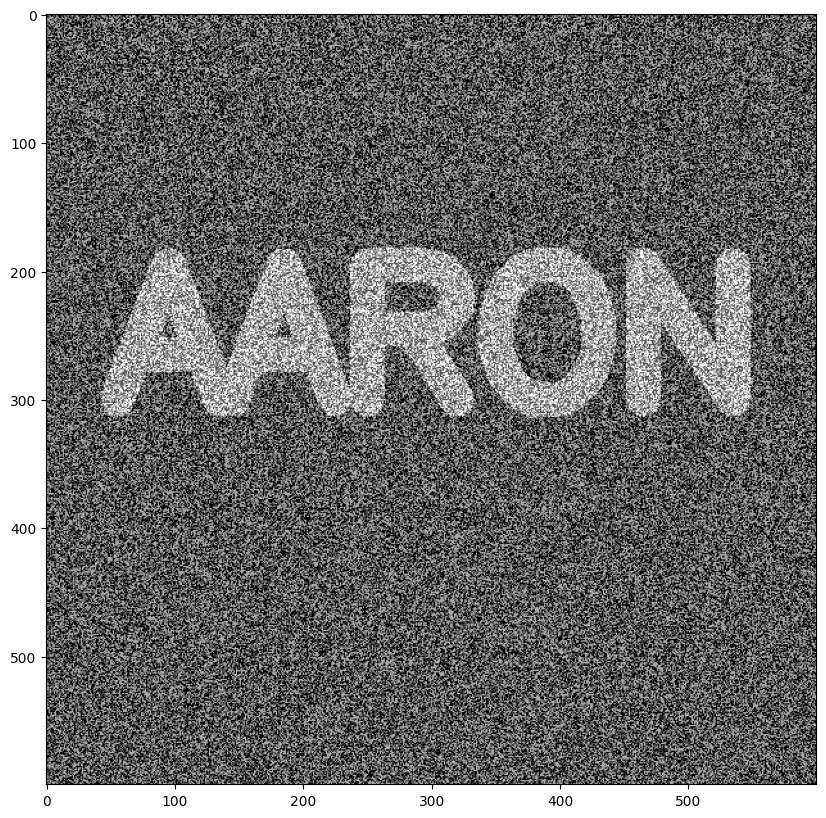

In [22]:
display_img(noise_img)   

In [23]:
opening = cv2.morphologyEx(noise_img, cv2.MORPH_OPEN, kernel)

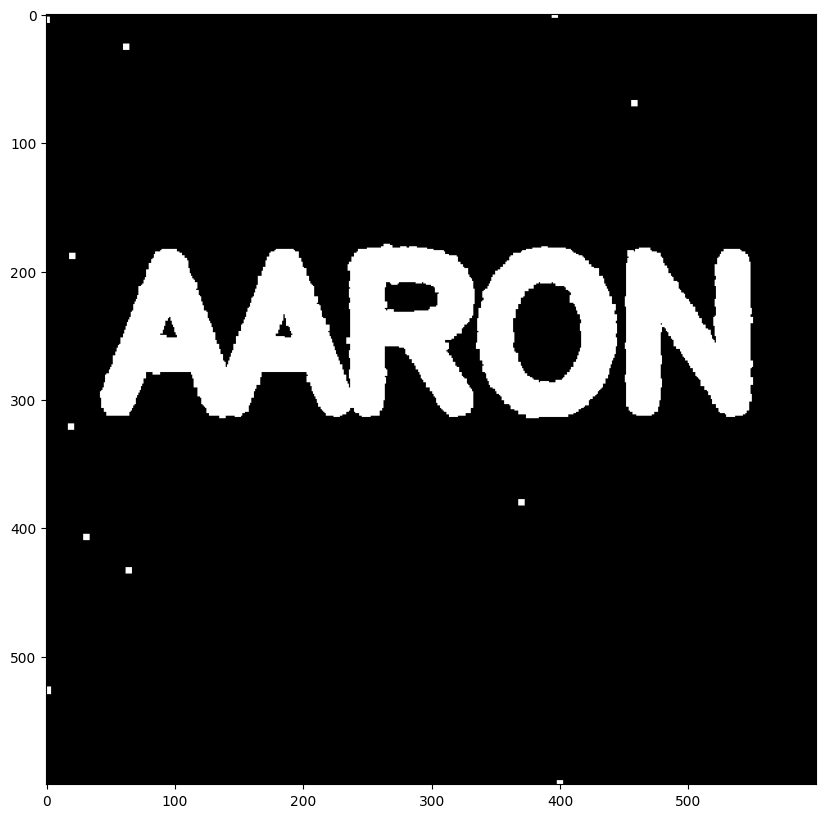

In [24]:
display_img(opening)

### Closing
 Useful in removing noise from foreground objects, such as black dots on top of the white text.

In [25]:
# creat white noise  with randint(low=0,high=2,size=(600,600)) 

In [26]:
img = load_img()

In [27]:
black_noise = np.random.randint(low=0,high=2,size=(600,600))

In [28]:
black_noise

array([[0, 0, 0, ..., 0, 1, 1],
       [1, 1, 1, ..., 1, 0, 0],
       [0, 0, 1, ..., 1, 1, 0],
       ...,
       [0, 0, 1, ..., 1, 0, 0],
       [0, 1, 1, ..., 1, 1, 1],
       [1, 0, 0, ..., 0, 1, 1]], shape=(600, 600), dtype=int32)

In [29]:
black_noise= black_noise * -255

In [30]:
black_noise_img = img + black_noise

In [31]:
black_noise_img     # display

array([[   0.,    0.,    0., ...,    0., -255., -255.],
       [-255., -255., -255., ..., -255.,    0.,    0.],
       [   0.,    0., -255., ..., -255., -255.,    0.],
       ...,
       [   0.,    0., -255., ..., -255.,    0.,    0.],
       [   0., -255., -255., ..., -255., -255., -255.],
       [-255.,    0.,    0., ...,    0., -255., -255.]], shape=(600, 600))

In [32]:
black_noise_img[black_noise_img==-255] = 0

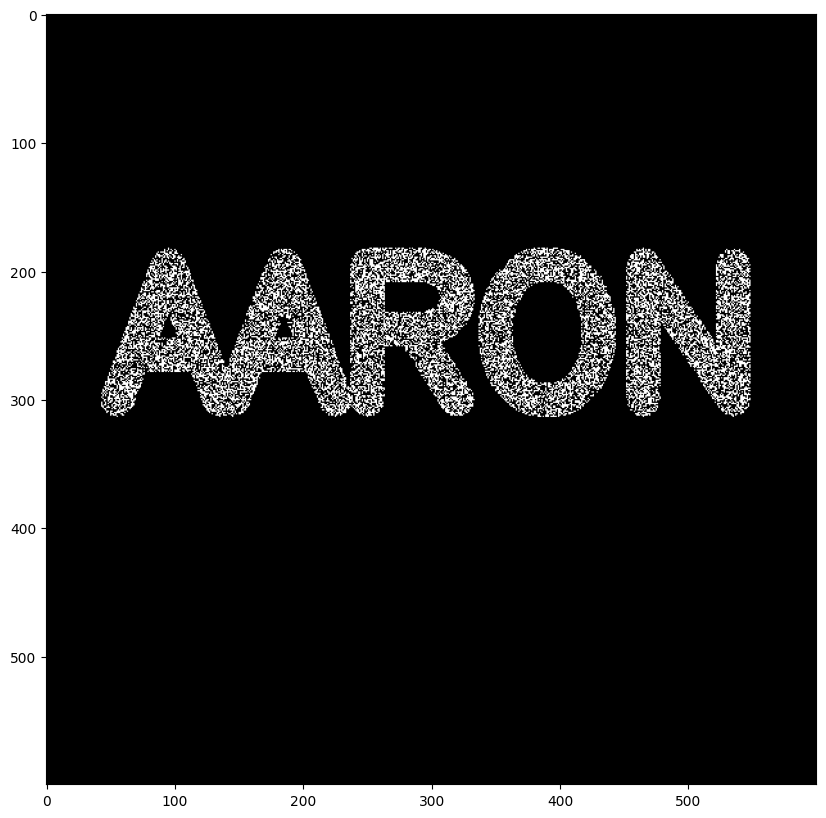

In [33]:
display_img(black_noise_img)

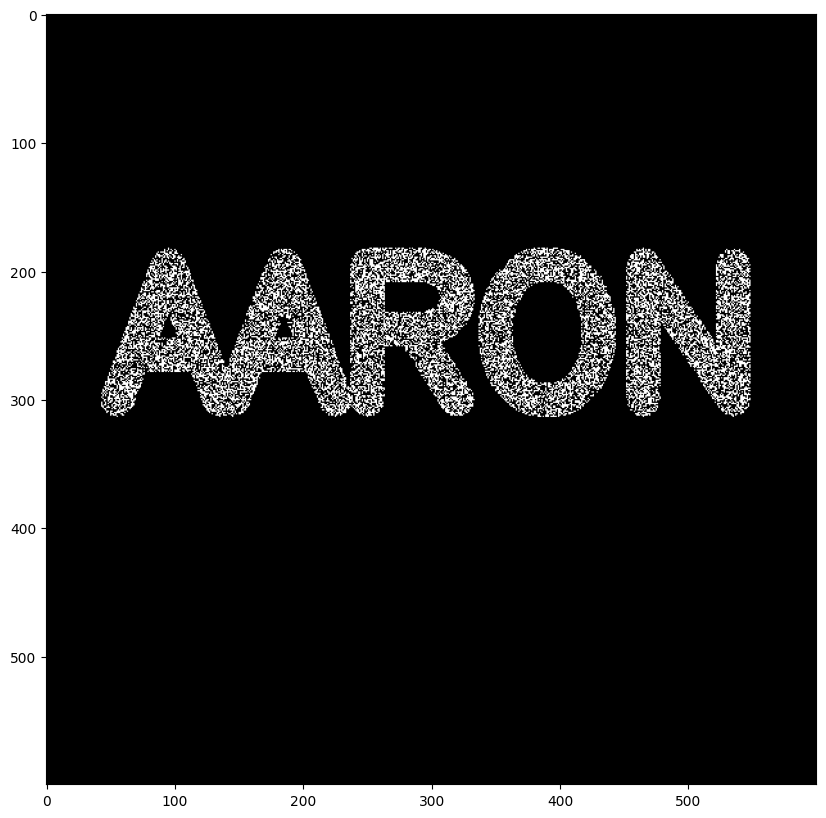

In [34]:
display_img(black_noise_img)

In [35]:
closing = cv2.morphologyEx(black_noise_img, cv2.MORPH_CLOSE, kernel)

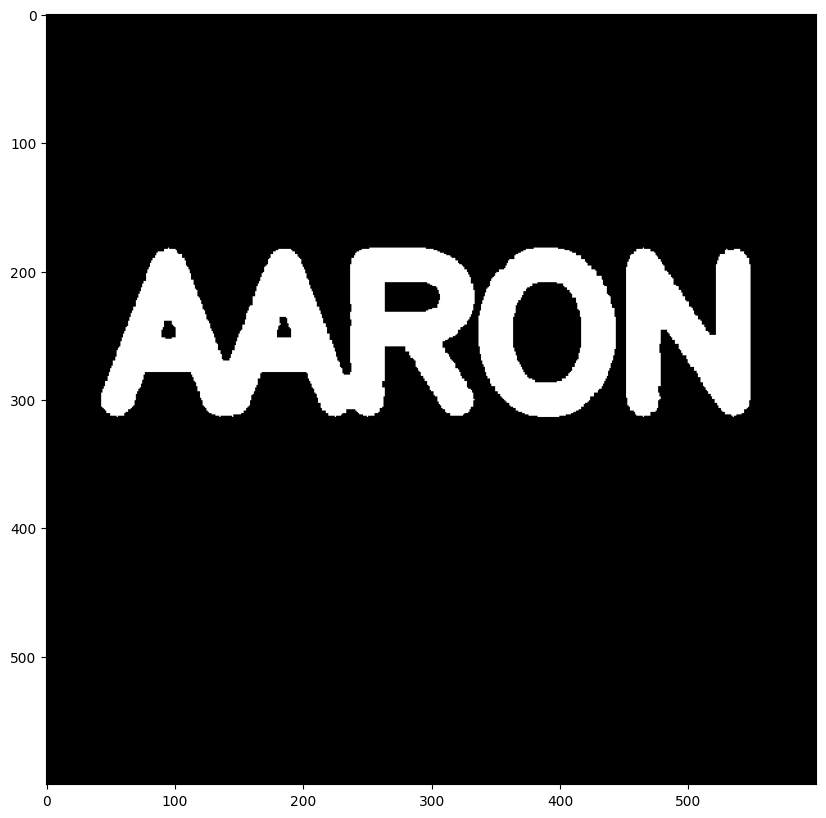

In [36]:
display_img(closing)

## Morphological Gradient

Difference between dilation and erosion of an image.

In [37]:
img = load_img()

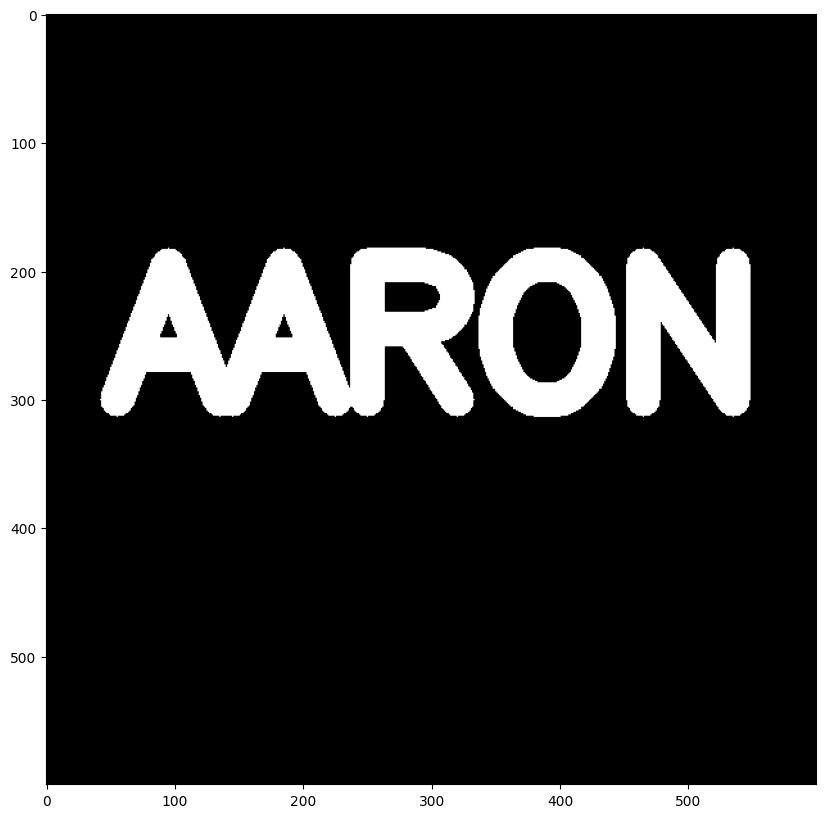

In [38]:
display_img(img)

In [39]:
gradient = cv2.morphologyEx(img,cv2.MORPH_GRADIENT,kernel)

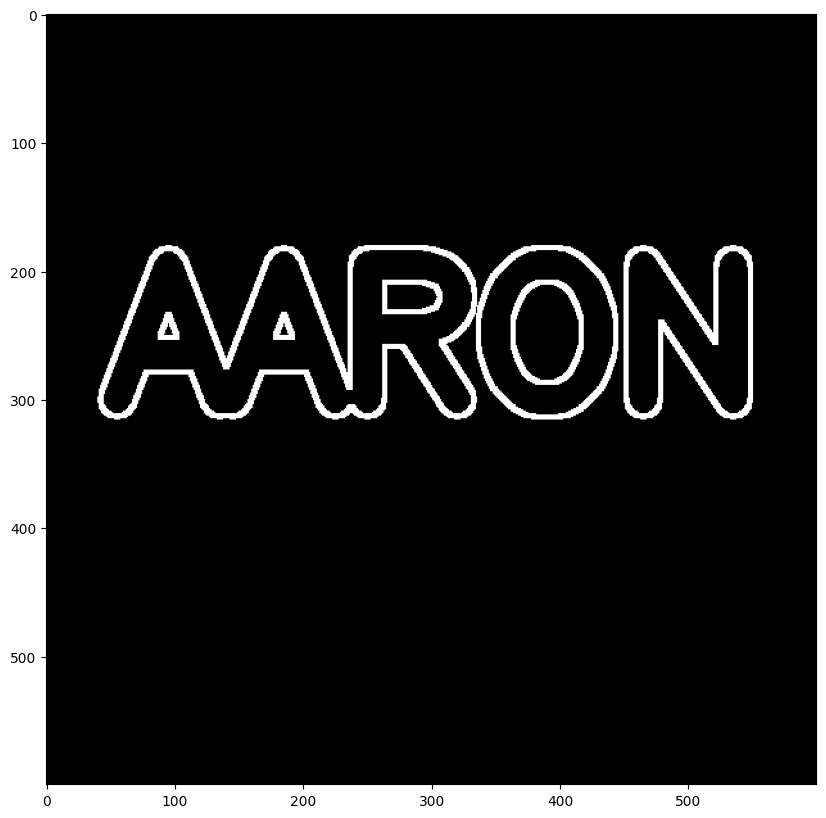

In [40]:
display_img(gradient)